<h4>Assessment 2 - Brief</h4>

* Analytic question formulation
* Data wrangling
* Data preparation and sampling
* Descriptive statistics
* Inferential statistics (Confidence interval)
* Inferential statistics (Two-sample t-Test)

Question: Likelihood of goalkeeper saving goals during the world cup (goalkeeper that played in world cup 2026)

Potential other analysis:
- inside the penalty area
- outside the penalty area

Note: 
- remove Rank and replace with player ID
- Does sample = population data
- We are to work with sample data calculate mean and proportion

Sample size = 61 goalkeepers (min 30-40 players)
1. give each player an id - From player csv
2. Randomly choose players - Can be randomly selected with python code
3. Review the glossary def for actions inside pa and actions outside pa
4. Calculate confidence interval - CI - Inferential stat
6. What confidence level - 95%
7. Sample T test - Compaire to previous years 2022 world cup
    - Use for hypothsis testing - Inferential stat (two-sample T test)
8. Create powerpoint of analysis of Goalkeeper saves during world cup 2026


<h3>Goalkeeping Definitions</h3>

<h3>Clean Sheets</h3>
- Matches in which a team does not concede any goals, typically used to evaluate defensive and goalkeeper performance.

<h3>Goals Conceded</h3>
- Goals Conceded indicate the total number of goals a team has allowed their opponent to score.

<h3>Goalkeeper Goal Preventions</h3>
- The total number of successful goalkeeping actions that prevent a goal from being scored, including any attempt at goal stopped or deflected by the goalkeeper using any part of the body within the rules.

<h3>Goalkeeper Actions Inside the Penalty Area</h3>
- All defensive interventions made by the goalkeeper within their own penalty area, including saves, punches, and claims.

<h3>Goalkeeper Actions Outside the Penalty Area</h3>
- All defensive interventions made by the goalkeeper outside their penalty area, often involving tackles or clearances.
<br>

In [1]:
import pandas as pd
import numpy as np
import statistics as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import scipy.stats as st
import math
import statsmodels.stats.proportion as stmp
import statsmodels.stats.weightstats as stm

In [2]:
goalkeeper = pd.read_csv("goalkeeper.csv")

In [24]:
goalkeeper.describe()

,Rank,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea
count,145.000000,145.000000,145.000000,145.000000
mean,46.082759,4.503448,28.268966,23.820690
std,18.102526,6.669920,40.155125,33.727393
min,1.000000,0.000000,0.000000,0.000000
25%,36.000000,0.000000,0.000000,0.000000
50%,58.000000,0.000000,0.000000,0.000000
75%,58.000000,8.000000,55.000000,46.000000
max,58.000000,28.000000,141.000000,124.000000


In [3]:
# Variance
gk_save_var = np.array(goalkeeper["Goalkeeper_Saves"])
gk_saves_square = gk_save_var.var(ddof=1) # sample var - degree of freedon (ddof)
gk_save_sigma_square = gk_save_var.var() # popluation var - no ddof required

print("variance s square: ", gk_saves_square)
print("var sigma square: ", gk_save_sigma_square)

variance s square:  44.48783524904214
var sigma square:  44.181022592152196


In [4]:
gk_inside_var = np.array(goalkeeper["Goalkeeper_Actions_inside_PenaltyArea"])
gk_inside_square = gk_inside_var.var(ddof=1) # sample var - degree of freedon (ddof)
gk_inside_sigma_square = gk_inside_var.var() # popluation var - no ddof required

print("variance s square: ", gk_inside_square)
print("var sigma square: ", gk_inside_sigma_square)

variance s square:  1612.4340996168585
var sigma square:  1601.3138644470869


In [5]:
# standard deviation
s = gk_save_var.std(ddof=1) # sample standard dev
sigma = gk_save_var.std()
print("standard deviation: %.2f" % s)
print("stad dev population: ", sigma)

standard deviation: 6.67
stad dev population:  6.646880666308986


In [21]:
percentile25th = (goalkeeper["Goalkeeper_Saves"]).quantile(0.25)
percentile50th = (goalkeeper["Goalkeeper_Saves"]).quantile(0.50) # check if same as median value = yes 11.0
percentile75th = (goalkeeper["Goalkeeper_Saves"]).quantile(0.75)

In [22]:
player = np.array(goalkeeper["Player"])
savesgk = np.array(goalkeeper["Goalkeeper_Saves"])
insidegk = np.array(goalkeeper["Goalkeeper_Actions_inside_PenaltyArea"])
outsidegk = np.array(goalkeeper["Goalkeeper_Actions_outside_PenaltyArea"])

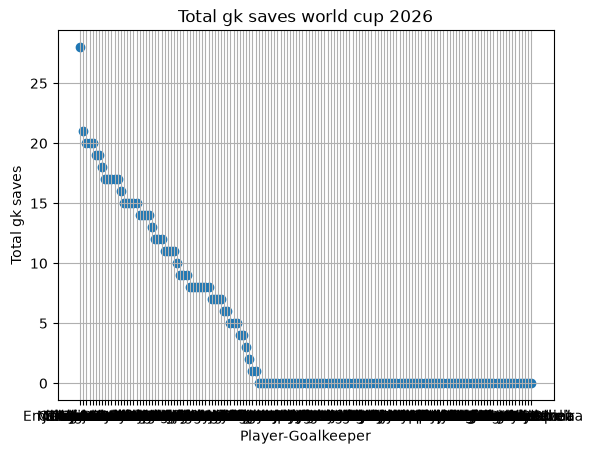

In [7]:
plt.scatter(player, savesgk)
plt.title("Total gk saves world cup 2026")
plt.xlabel("Player-Goalkeeper")
plt.ylabel("Total gk saves")
plt.grid()
plt.show()

In [8]:
# GK saves
gk_saves = goalkeeper.Goalkeeper_Saves.values
# GK saves inside the penalty area
gk_saves_ipa = goalkeeper.Goalkeeper_Actions_inside_PenaltyArea.values
# GK saves oudise penalty area
gk_saves_opa = goalkeeper.Goalkeeper_Actions_outside_PenaltyArea.values
print(gk_saves)
print(gk_saves_ipa)
print(gk_saves_opa)

[28 21 20 20 20 19 19 18 17 17 17 17 17 16 15 15 15 15 15 14 14 14 14 13
 12 12 12 11 11 11 11 10  9  9  9  8  8  8  8  8  8  8  7  7  7  7  6  6
  5  5  5  4  4  3  2  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
[141  81 111 100 114 133 112 136  78  86 107  57 110 124  75  83 108  85
  67 119  72  91 120  56  80  54  68  84  42  97  60  58  48  75  34  70
  57  34  31  55  55  92  57  51  49  61  26  51  53  55  25  41  22  43
   7  26  27   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0  14   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0  21   0   0   0   0   0   0   0  

Text(0, 0.5, 'Goalkeeper')

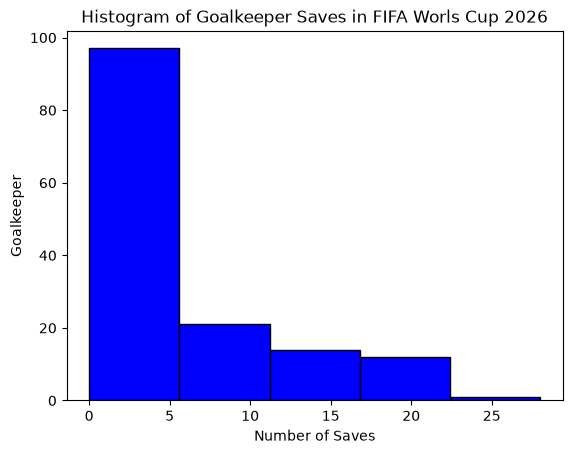

In [9]:
# set up the histogram parameters for goalkeeper saves
max_val = gk_saves.max()
min_val = gk_saves.min()
the_range = max_val - min_val
bin_width = 5 # smaller bin width gives more detail, but can be noisy
bin_count = int(the_range / bin_width)

# create the histogram for goalkeeper saves
plt.hist(gk_saves, bins=bin_count, range=(min_val, max_val), color='blue', edgecolor='black')
plt.title('Histogram of Goalkeeper Saves in FIFA Worls Cup 2026')
plt.xlabel('Number of Saves')
plt.ylabel('Goalkeeper')

Text(0, 0.5, 'add text here')

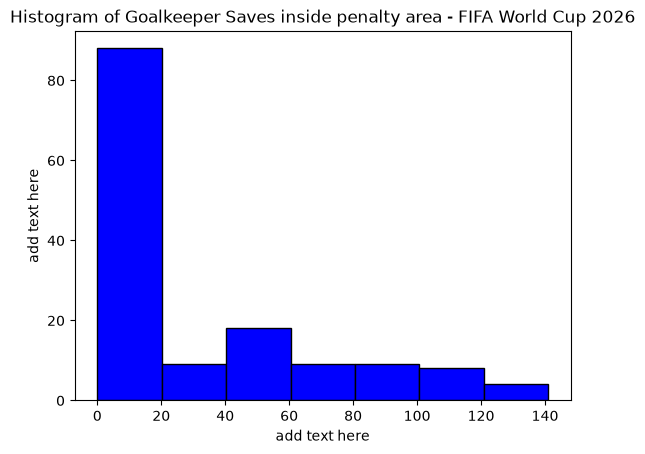

In [10]:
# set up the histogram parameters for goalkeeper saves inside penalty area
max_val_ipa = gk_saves_ipa.max()
min_val_ipa = gk_saves_ipa.min()
the_range_ipa = max_val_ipa - min_val_ipa
bin_width_ipa = 20 # smaller bin width gives more detail, but can be noisy
bin_count_ipa = int(the_range_ipa / bin_width_ipa)

# create the histogram for goalkeeper saves inside penalty area
plt.hist(gk_saves_ipa, bins=bin_count_ipa, range=(min_val_ipa, max_val_ipa), color='blue', edgecolor='black')
plt.title('Histogram of Goalkeeper Saves inside penalty area - FIFA World Cup 2026')
plt.xlabel('add text here')
plt.ylabel('add text here')

Text(0, 0.5, 'add text here')

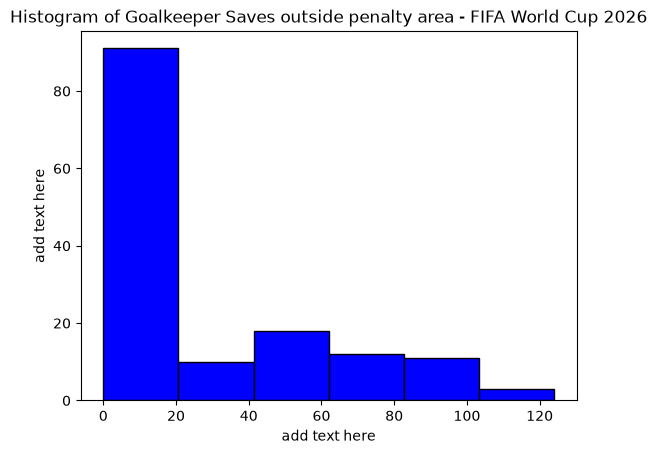

In [11]:
# set up the histogram parameters for goalkeeper saves outside penalty area
max_val_opa = gk_saves_opa.max()
min_val_opa = gk_saves_opa.min()
the_range_opa = max_val_opa - min_val_opa
bin_width_opa = 20 # smaller bin width gives more detail
bin_count_opa = int(the_range_opa / bin_width_opa)

# create the histogram for goalkeeper saves outside penalty area
plt.hist(gk_saves_opa, bins=bin_count_opa, range=(min_val_opa, max_val_opa), color='blue', edgecolor='black')
plt.title('Histogram of Goalkeeper Saves outside penalty area - FIFA World Cup 2026')
plt.xlabel('add text here')
plt.ylabel('add text here')

<table>
<tr>
<th>Goalkeeper_Saves</th>
<th>Goalkeeper_Actions_inside_PenaltyArea</th>
<th>Goalkeeper_Actions_outside_PenaltyArea</th>
</tr>
<tr>
<td>count 61.000000<br>mean 10.704918<br>std 6.267228<br>min 0.00<br>IQR 25% 7.000000<br>IQR 50% 11.000000<br>IQR 75% 15.000000<br>max 28.000000</td>
<td>count 61.000000<br>mean 67.196721<br>std 34.791196<br>min 3.0000<br>IQR 25% 43.000000<br>IQR 50% 60.000000<br>IQR 75% 91.000000<br>max 141.000000</td>
<td>count 61.000000<br>mean 56.622951<br>std 29.013310<br>min 3.000000<br>min 3.000000<br>IQR 25% 36.000000<br>IQR 50% 54.000000<br>IQR 75% 76.000000<br>max 124.000000</td>
</tr>
</table>

In [12]:
# create mean, median and sample size values for goalkeeper saves, inside penalty area and outside penalty area
gk_s_mean = goalkeeper["Goalkeeper_Saves"].mean()
gk_ipa_mean = goalkeeper["Goalkeeper_Actions_inside_PenaltyArea"].mean()
gk_opa_mean = goalkeeper["Goalkeeper_Actions_outside_PenaltyArea"].mean()
gk_s_median = goalkeeper["Goalkeeper_Saves"].median()
gk_ipa_median = goalkeeper["Goalkeeper_Actions_inside_PenaltyArea"].median()
gk_opa_median = goalkeeper["Goalkeeper_Actions_outside_PenaltyArea"].median()
gk_s_sample_size = len(goalkeeper["Goalkeeper_Saves"])
gk_ipa_sample_size = len(goalkeeper["Goalkeeper_Actions_inside_PenaltyArea"])
gk_opa_sample_size = len(goalkeeper["Goalkeeper_Actions_outside_PenaltyArea"])

In [13]:
# calculation confidence interval goalkeeper saves
ci_low, ci_upp = stm._zconfint_generic(gk_s_mean, gk_s_sample_size / math.sqrt(gk_s_sample_size), alpha=0.05, alternative='two-sided') # 95% confidence interval aplpha=0.05 or 5%
print("CI Lower gk saves: %.2f to %.2f" % (ci_low, ci_upp))

CI Lower gk saves: -19.10 to 28.10


In [14]:
# calculation confidence interval goalkeeper saves inside penalty area
ci_low, ci_upp = stm._zconfint_generic(gk_ipa_mean, gk_ipa_sample_size / math.sqrt(gk_ipa_sample_size), alpha=0.05, alternative='two-sided') # 95% confidence interval aplpha=0.05 or 5%
print("CI Lower gk ipa: %.2f to %.2f" % (ci_low, ci_upp))

CI Lower gk ipa: 4.67 to 51.87


In [15]:
# calculation confidence interval goalkeeper saves outside penalty area
ci_low, ci_upp = stm._zconfint_generic(gk_opa_mean, gk_opa_sample_size / math.sqrt(gk_opa_sample_size), alpha=0.05, alternative='two-sided') # 95% confidence interval aplpha=0.05 or 5%
print("CI Lower gk opa: %.2f to %.2f" % (ci_low, ci_upp))

CI Lower gk opa: 0.22 to 47.42


In [16]:
import pandas as pd
from scipy import stats

# Extract the saves column
gk_savest_stat = goalkeeper["Goalkeeper_Saves"].values

# Hypothesized mean 
mu_0 = 10.70

# Compute t-statistic and p-value
t_stat, p_value = stats.ttest_1samp(gk_savest_stat, mu_0)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -11.18699498646882
p-value: 2.6764893949596578e-21


In [17]:
gk_saves_t_stat = 0.006128876481186812
gk_saves_p_value = 0.9951302273130959

In [18]:
# create sample from 2022
goalkeeper2022 = pd.read_csv("gkstats2022.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'gkstats2022.csv'

In [ ]:
# create sample from goalkepper 2026 FIFA World Cup
sample_gk_t_test_2026 = goalkeeper.sample(n=30, random_state=42)   # randomly select 30 rows random_state=42 is a seed for the random number generator FIFA 2026
print(sample_gk_t_test_2026)

sample_gk_t_test_2026.describe()

In [ ]:
# create sample from goalkepper 2022 FIFA World Cup
sample_gk_t_test_2022 = goalkeeper2022.sample(n=30, random_state=42)   # randomly select 30 rows random_state=42 is a seed for the random number generator FIFA 2022
print(sample_gk_t_test_2022)

sample_gk_t_test_2022.describe()

In [ ]:
# 2026 sample values in numpy this is required to run py code in the notebook
sample = np.array(sample_gk_t_test_2026.Goalkeeper_Saves.values)

# compute mean and standard deviation of the sample
print("Computing the basic statistics ...")
x_bar = st.tmean(sample)
s = st.tstd(sample)
print("\t Sample mean: %.2f" % x_bar)
print("\t Sample std. dev.: %.2f" % s)

# perform one-sample t-test
# null hypothesis: population mean = 10.033333333333333
# alternative hypothesis: population mean > 10.033333333333333 (in the function below, note the argument 'greater')
t_stats, p_val = st.ttest_1samp(sample, 10.033333333333333, alternative='greater')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")

In [ ]:
# 2022 sample values in numpy this is required to run py code in the notebook
sample2 = np.array(sample_gk_t_test_2022.Saves2022.values)

# compute mean and standard deviation of the sample2
print("Computing the basic statistics ...")
x_bar2 = st.tmean(sample2)
s2 = st.tstd(sample2)
print("\t Sample mean: %.2f" % x_bar2)
print("\t Sample std. dev.: %.2f" % s2)

# perform one-sample t-test
# null hypothesis: population mean = 7.9
# alternative hypothesis: population mean > 7.9 (in the function below, note the argument 'greater')
t_stats, p_val = st.ttest_1samp(sample2, 7.9, alternative='greater')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")

In [ ]:
# two samples to be tested, instead of raw sample values.
# the basic statistics of sample 1 2026:
x_bar1 = sample.mean()
s1 = sample.std()
n1 = len(sample)

# the basic statistics of sample 2 2022:
x_bar2 = sample2.mean()
s2 = sample2.std()
n2 = len(sample2)

# perform two-sample t-test
# null hypothesis: mean of sample 1 = mean of sample 2
# alternative hypothesis: mean of sample 1 does not equal mean of sample 2 (two-sided test)
# note the argument equal_var=False, which assumes that two populations do not have equal variance
t_stats, p_val = st.ttest_ind_from_stats(x_bar1, s1, n1, x_bar2, s2, n2, equal_var=False, alternative='two-sided')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")